# part4 시각화 도구

**1. Matplotlib**

- 2D 평면 그래프에 관한 다양한 포맷과 기능을 지원
- 객체지향 프로그래밍을 지원하므로 그래프 요소를 세세하게 꾸밀 수 있음

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.getcwd())
!find /content/drive -name "시도별_전출입_인구수.xlsx"

/content


**1-1. 선그래프**

- 연속하는 데이터 값들을 직선 or 곡선으로 연결하여 데이터 값 사이의 관계를 나타냄
- 시계열 데이터와 같이 연속적인 값의 변화와 패턴을 파악하는데 적합

- 차트 제목, 축 이름 추가

- matplotlib 한글 폰트 오류 해결

In [3]:
!apt-get -qq update
!apt-get -qq install fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 폰트 찾기
font_files = fm.findSystemFonts(
    fontpaths=['/usr/share/fonts/truetype/nanum']
)

print(font_files)

['/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf']


In [5]:
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_name = fm.FontProperties(fname=font_path).get_name()

print(font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

NanumGothic


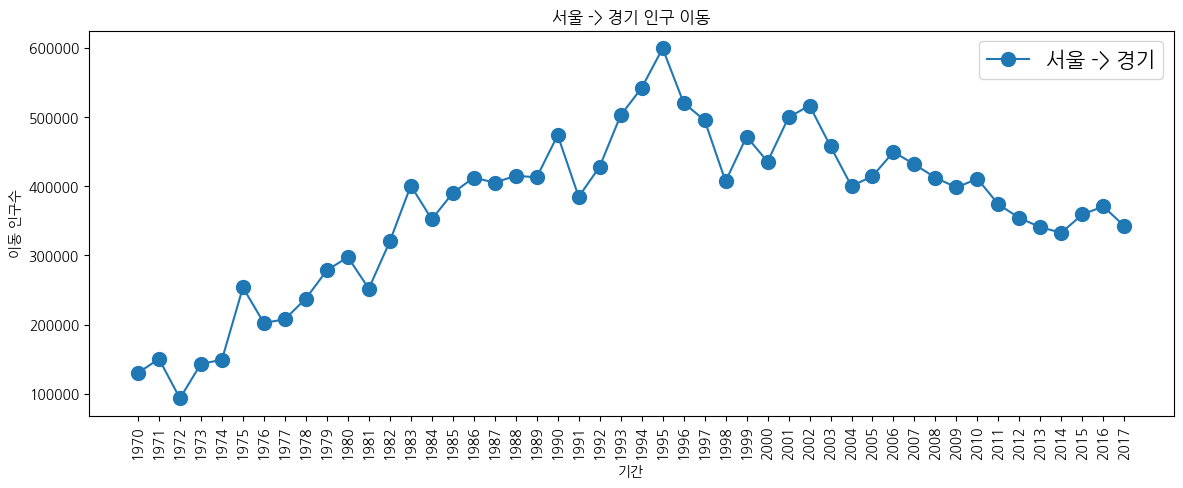

In [6]:
# 예제 4-1: 선그래프
# 예제 4-2: 차트 제목
# 예제 4-3: 축 이름 추가 + 한글폰트오류해결
# 예제 4-4: 그래프 꾸미기
# 예제 4-5: 스타일 서식 지정

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 경기도로 이동한 데이터값만 선택
sr_one = df_seoul.loc['경기도']

# 그림 사이즈 지정(가로 14인치, 새로 5인치)
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(rotation='vertical')

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values, marker = 'o', markersize= 10)

# 차트 제목 추가
plt.title('서울 -> 경기 인구 이동')

# 축 이름 추가
plt.xlabel('기간')
plt.ylabel('이동 인구수')

# 범례 표시
plt.legend(labels = ['서울 -> 경기'], loc = 'best', fontsize= 15)

# 스타일 서식 지정
plt.style.use('ggplot')

plt.show() # 변경사항 저장하고 그래프 출력

In [7]:
# 예제 4-6: Matplotlib 스타일 리스트 출력

# 라이브러리 불러오기

import matplotlib.pyplot as plt

# 스타일 리스트 출력
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


-----------------------------------------------------------------


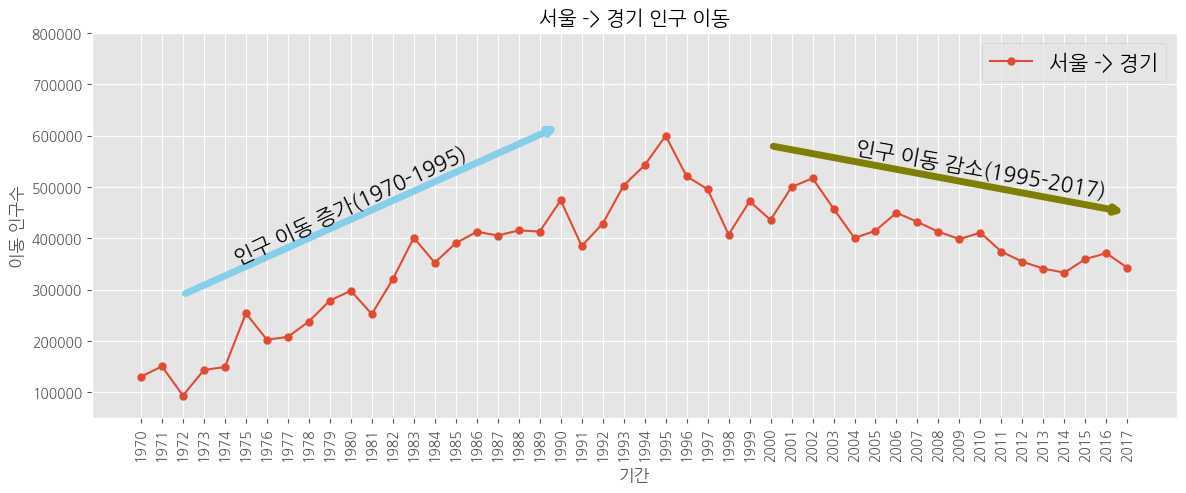

In [8]:
# 예제 4-7: matplotlib 스타일 리스트 출력

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 경기도로 이동한 데이터값만 선택
sr_one = df_seoul.loc['경기도']

# 그림 사이즈 지정(가로 14인치, 새로 5인치)
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(rotation='vertical')

# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values, marker = 'o', markersize= 5)

# 차트 제목 추가
plt.title('서울 -> 경기 인구 이동')

# 축 이름 추가
plt.xlabel('기간')
plt.ylabel('이동 인구수')

# 범례 표시
plt.legend(labels = ['서울 -> 경기'], loc = 'best', fontsize= 15)


print('-----------------------------------------------------------------')

# y축 범위 지정(최소값, 최대값)
plt.ylim(50000, 800000)

# 주석 표시 - 화살표
plt.annotate('',
             xy=(20, 620000),     # 화살표의 머리 부분(끝점)
             xytext = (2, 290000),    # 화살표의 꼬리 부분(시작점)
             xycoords = 'data',    # 좌표체계
             arrowprops = dict(arrowstyle = '->', color = 'skyblue', lw = 5),     # 화살표 서식
)

# 주석 표시 - 화살표
plt.annotate('',
             xy=(47, 450000),     # 화살표의 머리 부분(끝점)
             xytext = (30, 580000),    # 화살표의 꼬리 부분(시작점)
             xycoords = 'data',    # 좌표체계
             arrowprops = dict(arrowstyle = '->', color = 'olive', lw = 5),     # 화살표 서식
)
# 주석 표시 - 텍스트
plt.annotate('인구 이동 증가(1970-1995)',    # 텍스트 입력
             xy = (10, 350000),    # 텍스트 위치 기준점
             rotation=25,     # 텍스트 회전 각도
             va='baseline',    # 텍스트 상하 정렬
             ha = 'center',    # 텍스트 좌우정렬
             fontsize=15,    # 텍스트 크기
             )

plt.annotate('인구 이동 감소(1995-2017)',
             xy=(40, 480000),
             rotation = -10,
             va = 'baseline',
             ha = 'center',
             fontsize = 15,
             )

plt.show()


- 화면 분할하여 그래프 여러 개 그리기 - axe 객체 활용
- 한 화면에서 여러 개의 그래프를 비교하거나 다양한 정보를 보여줄 때 사용하면 좋음

/tmp/ipykernel_667/2938725031.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sr_one.index, rotation = 75)
/tmp/ipykernel_667/2938725031.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(sr_one.index, rotation = 75)


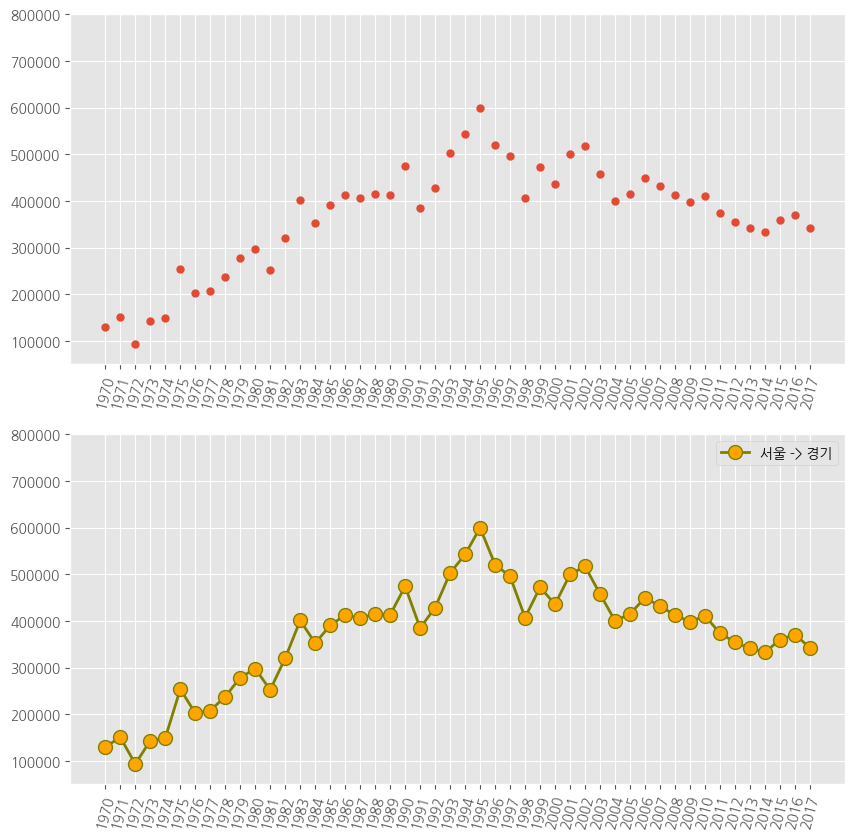

In [9]:
# 예제 4-8: matplotlib 소개

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)


# 그래프 객체 생성(figure에 2개의 서브플롯 생성)
fig = plt.figure(figsize = (10,10))

# add_subplot(행, 열, 위치)
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

# axe 객체에 plot 함수로 그래프 출력
ax1.plot(sr_one, 'o', markersize= 5)   # 점그래프로 표현
ax2.plot(sr_one, marker = 'o', markerfacecolor = 'orange', markersize= 10,
         color = 'olive', linewidth = 2, label= '서울 -> 경기')
ax2.legend(loc = 'best')

# y축 범위 지정(최소값, 최대값)
ax1.set_ylim(50000, 800000)
ax2.set_ylim(50000, 800000)

# 축 눈금 라벨 지정 및 75도 회전
ax1.set_xticklabels(sr_one.index, rotation = 75)
ax2.set_xticklabels(sr_one.index, rotation = 75)

plt.show()

/tmp/ipykernel_667/440636058.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sr_one.index, rotation = 75)


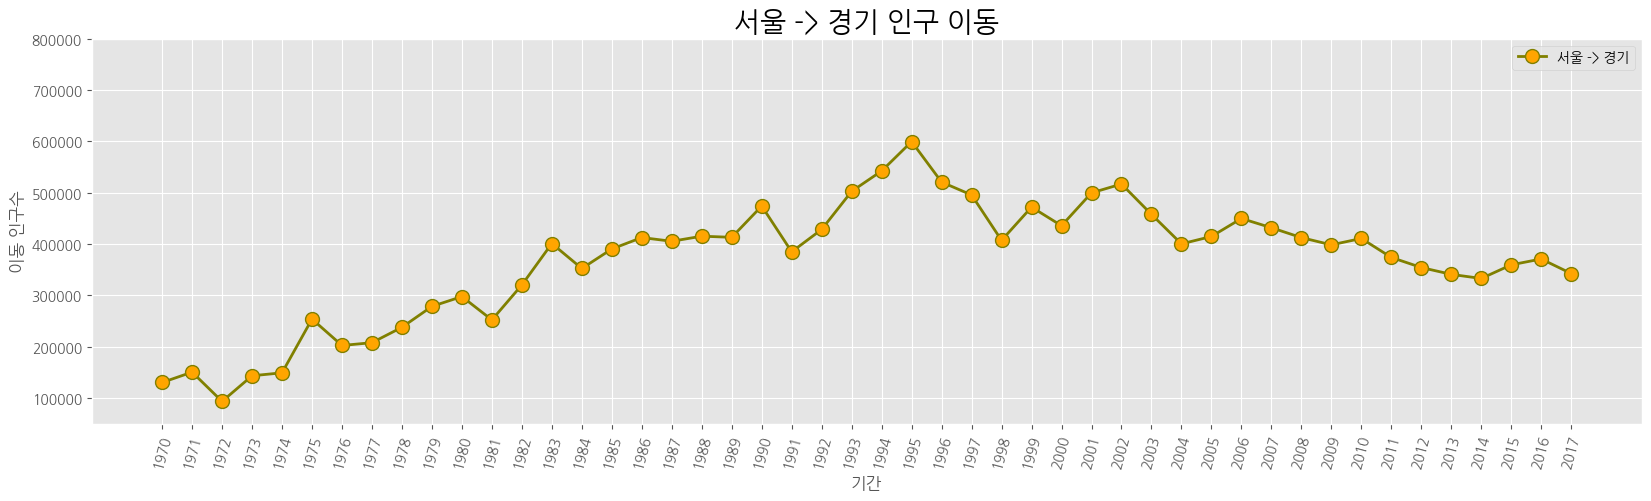

In [10]:
# 예제 4-9: axe 객체 그래프 꾸미기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)


# 그래프 객체 생성(figure에 2개의 서브플롯 생성)
fig = plt.figure(figsize = (20,5))

# add_subplot(행, 열, 위치)
ax = fig.add_subplot(1, 1, 1)


# axe 객체에 plot 함수로 그래프 출력
ax.plot(sr_one, marker = 'o', markerfacecolor = 'orange', markersize= 10,
         color = 'olive', linewidth = 2, label= '서울 -> 경기')
ax.legend(loc = 'best')

# y축 범위 지정(최소값, 최대값)
ax.set_ylim(50000, 800000)

# 차트 제목 추가
ax.set_title('서울 -> 경기 인구 이동', size = 20)

# 축 이름 추가
ax.set_xlabel('기간', size =12)
ax.set_ylabel('이동 인구수', size = 12)

# 축 눈금 라벨 지정 및 75도 회전
ax.set_xticklabels(sr_one.index, rotation = 75)

# 축 눈금 라벨 크기
ax.tick_params(axis = 'x', labelsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)

plt.show()

/tmp/ipykernel_667/2241946103.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(col_years, rotation = 90)


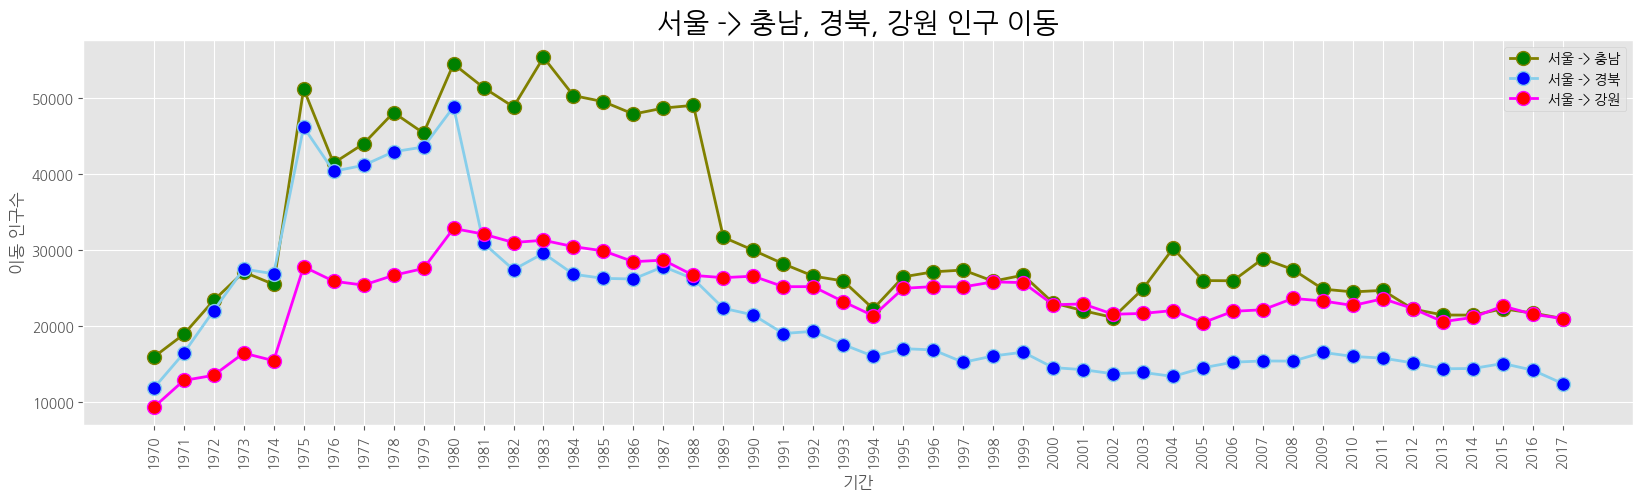

In [11]:
# 예제 4-10: 같은 화면에 그래프 추가

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_3 = df_seoul.loc[['충청남도', '경상북도', '강원도'],col_years]

# 스타일 서식 지정
plt.style.use('ggplot')

# 그래프 객체 생성(figure에 1개의 서브플롯 생성)
fig = plt.figure(figsize = (20,5))
ax = fig.add_subplot(1,1,1)

# axe 객체에 plot 함수로 그래프 출력
ax.plot(col_years, df_3.loc['충청남도', :], marker = 'o', markerfacecolor = 'green',
        markersize = 10, color = 'olive', linewidth = 2, label= '서울 -> 충남')
ax.plot(col_years, df_3.loc['경상북도', :], marker = 'o', markerfacecolor = 'blue',
        markersize = 10, color = 'skyblue', linewidth = 2, label= '서울 -> 경북')
ax.plot(col_years, df_3.loc['강원도', :], marker = 'o', markerfacecolor = 'red',
        markersize = 10, color = 'magenta', linewidth = 2, label= '서울 -> 강원')

# 범례표시
ax.legend(loc = 'best')

# 차트 제목 추가
ax.set_title('서울 -> 충남, 경북, 강원 인구 이동', size = 20)

# 축 이름 추가
ax.set_xlabel('기간', size = 12)
ax.set_ylabel('이동 인구수', size = 12)

# 축 눈금 라벨 지정 및 90도 회전
ax.set_xticklabels(col_years, rotation = 90)

# 축 눈금 라벨 크기
ax.tick_params(axis = 'x', labelsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)

plt.show()

/tmp/ipykernel_667/2622013450.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(col_years, rotation = 90)
/tmp/ipykernel_667/2622013450.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(col_years, rotation = 90)
/tmp/ipykernel_667/2622013450.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(col_years, rotation = 90)
/tmp/ipykernel_667/2622013450.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(col_years, rotation = 90)


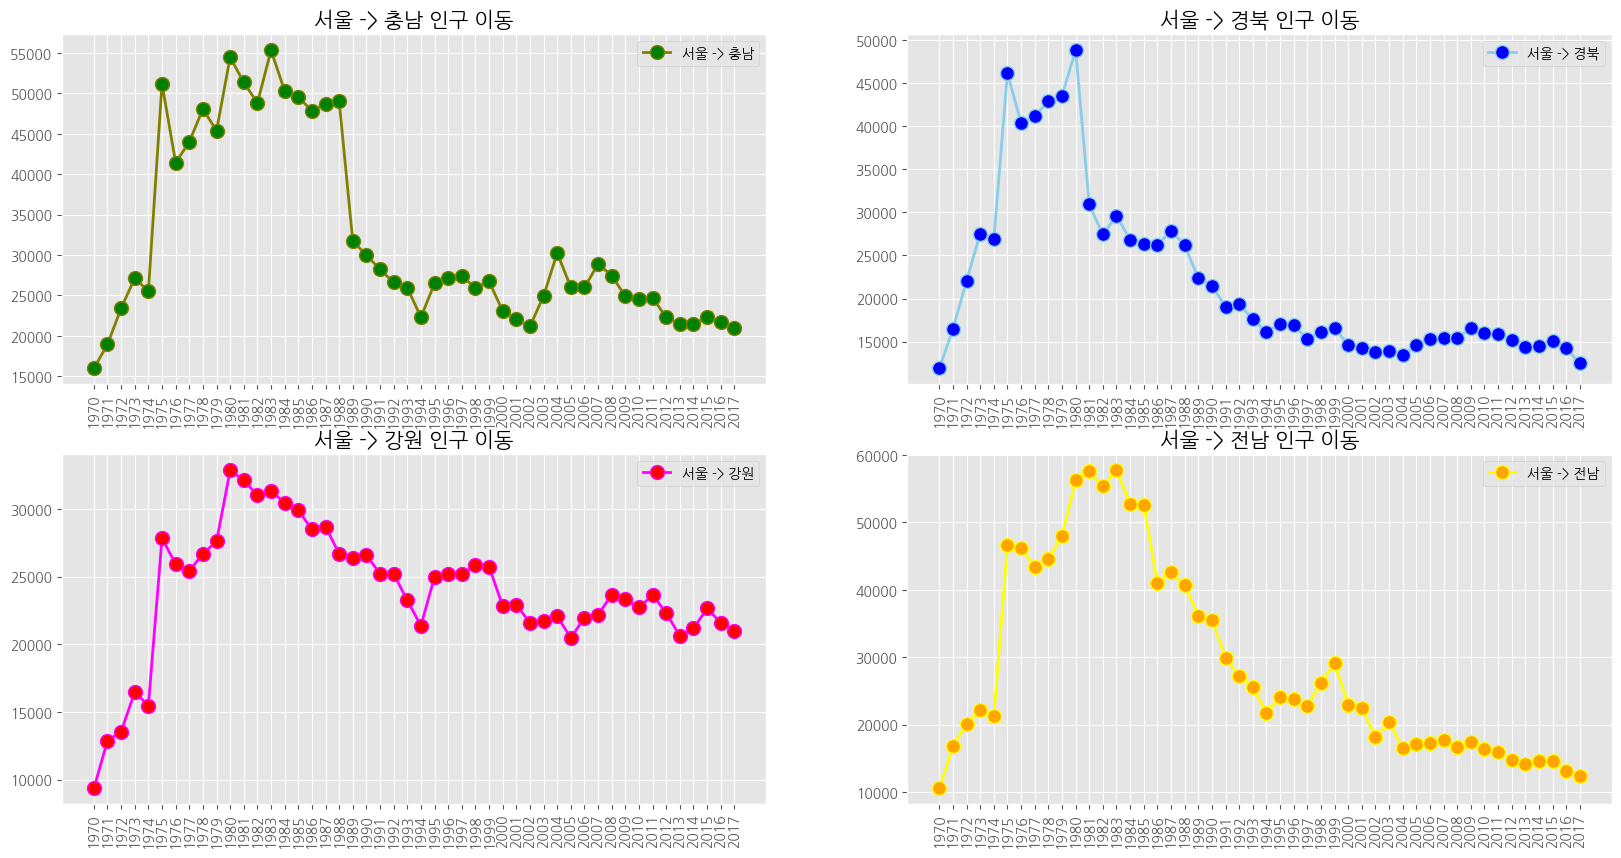

In [12]:
# 예제 4-11: 화면 4분할 그래프

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

# 스타일 서식 지정
plt.style.use('ggplot')

# 그래프 객체 생성(figure에 1개의 서브 플롯 생성)
fig = plt.figure(figsize =(20, 10))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

# axe 객체에 plot 함수로 그래프 출력
ax1.plot(col_years, df_4.loc['충청남도',:], marker = 'o', markerfacecolor = 'green',
         markersize = 10, color = 'olive', linewidth = 2, label= '서울 -> 충남')
ax2.plot(col_years, df_4.loc['경상북도',:], marker = 'o', markerfacecolor = 'blue',
         markersize = 10, color = 'skyblue', linewidth = 2, label= '서울 -> 경북')
ax3.plot(col_years, df_4.loc['강원도',:], marker = 'o', markerfacecolor = 'red',
         markersize = 10, color = 'magenta', linewidth = 2, label= '서울 -> 강원')
ax4.plot(col_years, df_4.loc['전라남도',:], marker = 'o', markerfacecolor = 'orange',
         markersize = 10, color = 'yellow', linewidth = 2, label= '서울 -> 전남')

# 범례표시
ax1.legend(loc = 'best')
ax2.legend(loc = 'best')
ax3.legend(loc = 'best')
ax4.legend(loc = 'best')

# 차트제목 추가
ax1.set_title('서울 -> 충남 인구 이동', size = 15)
ax2.set_title('서울 -> 경북 인구 이동', size = 15)
ax3.set_title('서울 -> 강원 인구 이동', size = 15)
ax4.set_title('서울 -> 전남 인구 이동', size = 15)

# 축 눈금 라벨 지정 및 90도 회전
ax1.set_xticklabels(col_years, rotation = 90)
ax2.set_xticklabels(col_years, rotation = 90)
ax3.set_xticklabels(col_years, rotation = 90)
ax4.set_xticklabels(col_years, rotation = 90)

plt.show()

In [13]:
# 예제 4-12 : matplotlib 스타일 리스트 출력

# 라이브러리 불러오기
import matplotlib

# 컬러 정보를 담을 빈 딕셔서리 생성
colors = {}

# 컬리 이름과 헥사코드 확인하여 딕셔너리에 입력
for name, hex in matplotlib.colors.cnames.items():
  colors[name] = hex

# 딕셔너리 출력
print(colors)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

**1-2 면저적그래프**

- 각 열의 데이터를 선 그래프로 구현, 선그래프와 x축 사이의 공간에 색이 입혀짐
- 투명도는 기본값 0.5로 투과되어 보임
- 그래프를 누적할지 여부를 설정할 수 있음(기본값: stacked = True)
- stacked = False 옵션을 지정하면 누적되지 않고 겹치도록 표시됨 - > 선 그래프를 동일한 화면에 여러개 그린 것과 같은 결과
- 각 열의 선 그래프를 다른 열의 선 그래프 위로 쌓아 올리는 방식으로 표현됨 -> 각 열의 패턴과 함께 열 전체의 합계가 어떻게 변하는지 파악할 수 있음
- 선그래프를 확장한 개념으로 누적 선 그래프(stacked line plot)라고 부르기도 함

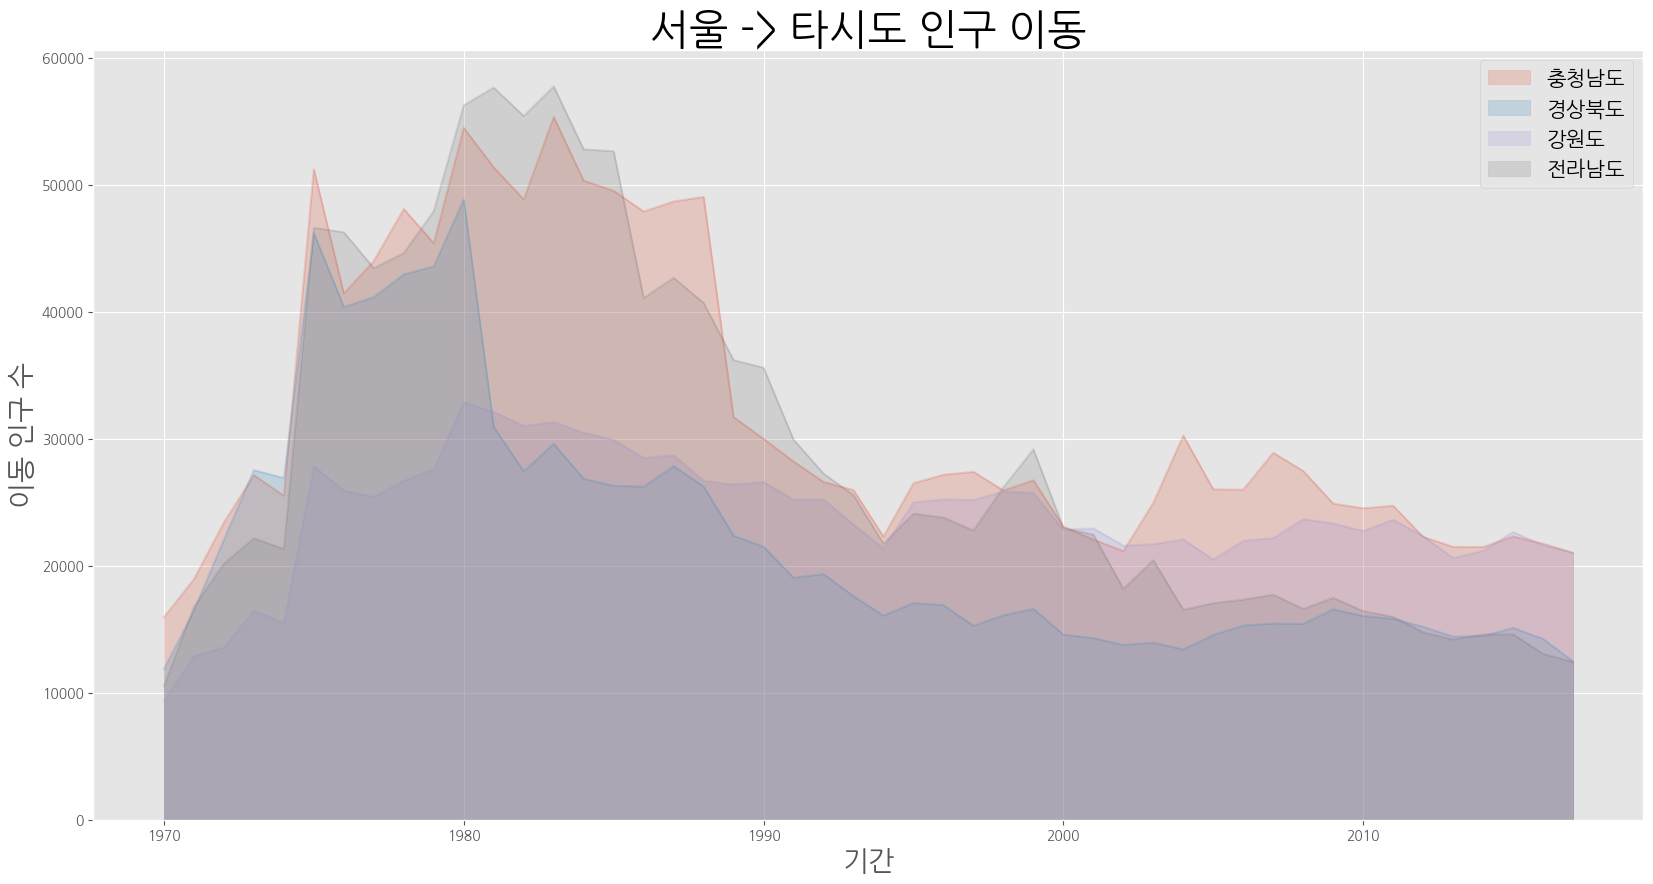

In [14]:
# 예제 4-13: 면적그래프(stacked = False) 그리기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.T

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 그리기
df_4.plot(kind = 'area', stacked = False, alpha = 0.2, figsize=(20,10))

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size = 20)
plt.legend(loc = 'best', fontsize = 15)

plt.show()

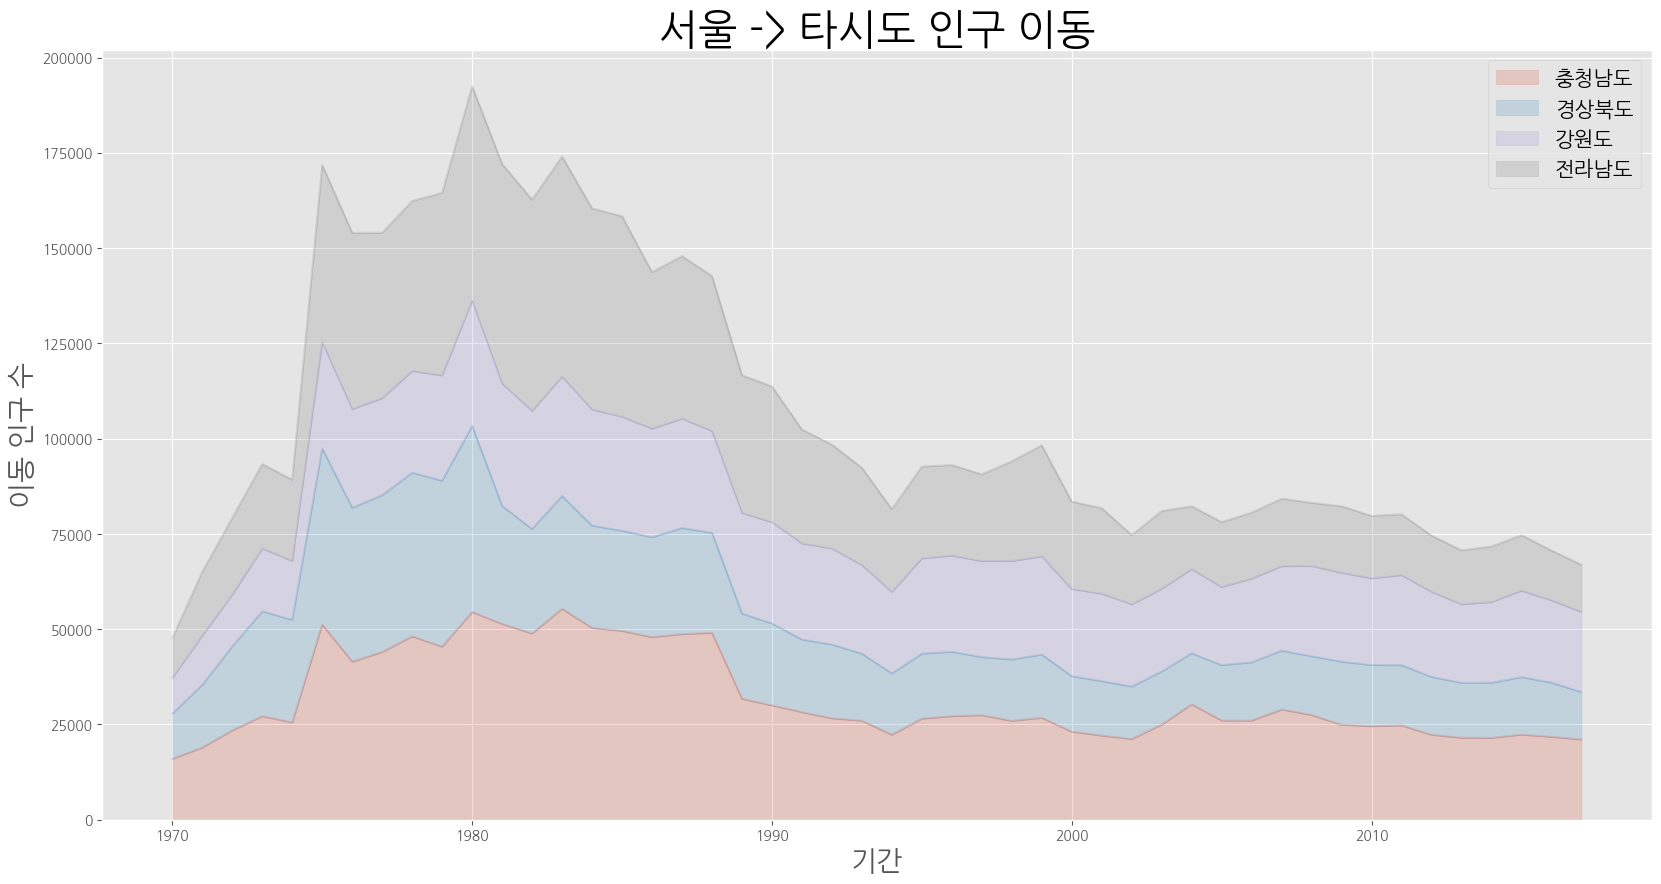

In [15]:
# 예제 4-14: 면적 그래프(stacked=False) 그리기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.T

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 그리기
df_4.plot(kind = 'area', stacked = True, alpha = 0.2, figsize=(20,10))

plt.title('서울 -> 타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size = 20)
plt.legend(loc = 'best', fontsize = 15)

plt.show()

<class 'matplotlib.axes._axes.Axes'>


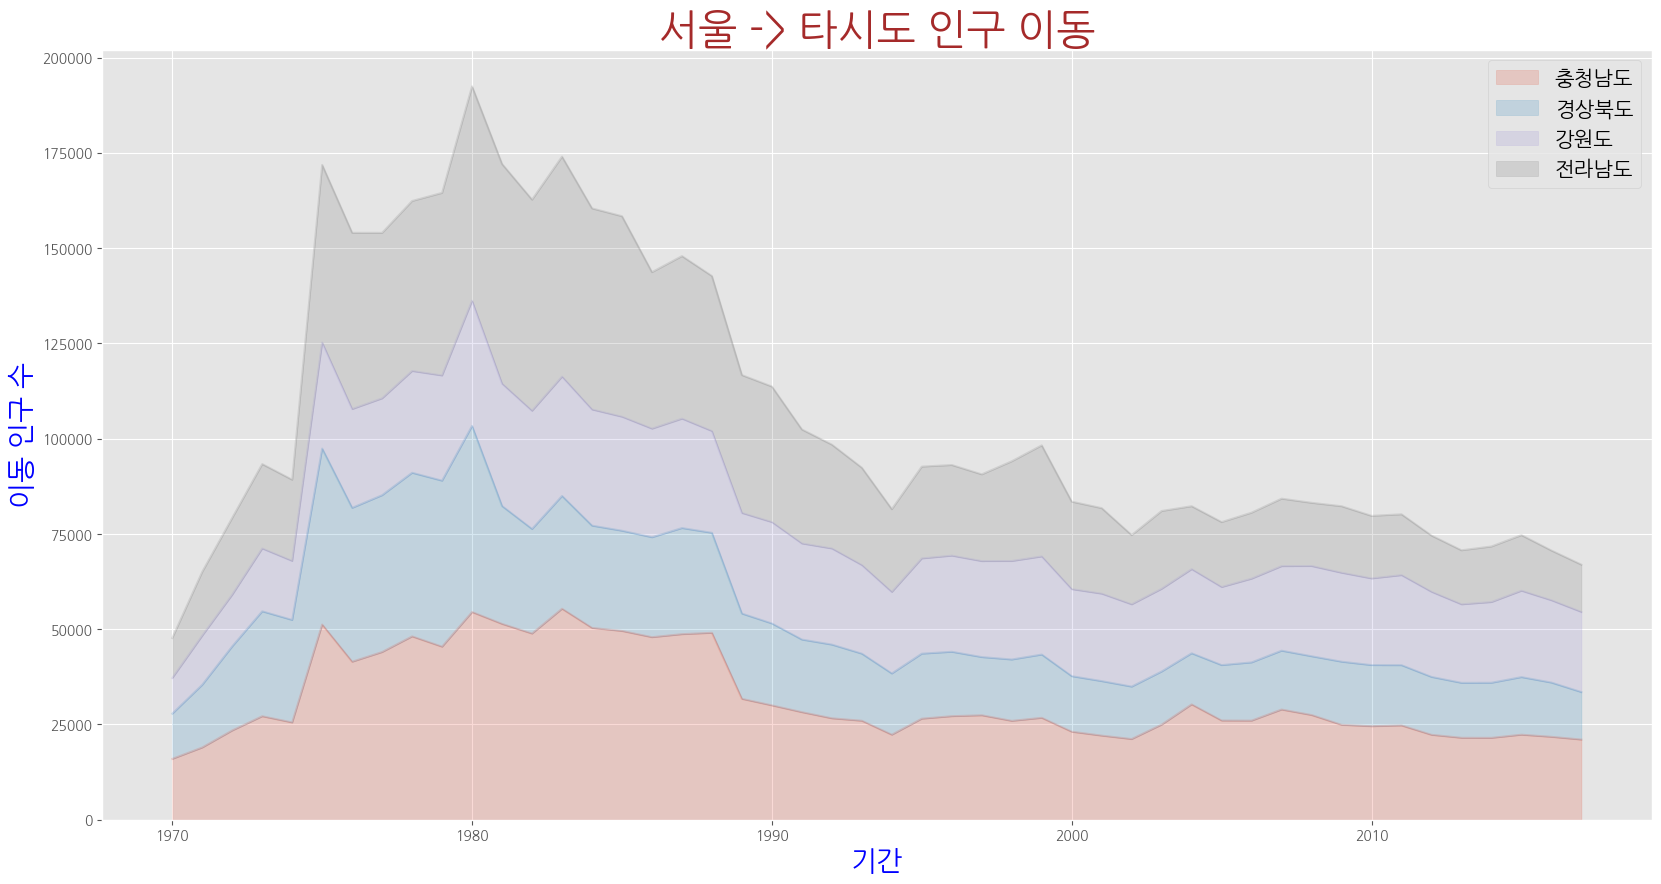

In [16]:
# 예제 4-15: axes 객체 속성 변경하기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.T

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 면적 그래프 axe 객체 생성
ax = df_4.plot(kind = 'area', stacked = True, alpha = 0.2, figsize=(20,10))
print(type(ax))

# axe 객체 설정 변경
ax.set_title('서울 -> 타시도 인구 이동', size=30, color = 'brown', weight = 'bold')
ax.set_ylabel('이동 인구 수', size=20, color ='blue')
ax.set_xlabel('기간', size = 20, color = 'blue')
ax.legend(loc = 'best', fontsize = 15)

plt.show()

**1-3 막대 그래프**
- 데이터 값의 크기에 비례하여 높이를 갖는 직사각형 막대로 표현
- 막대 높이의 상대적 길이 차이를 통해 값의 크고 작음을 설명함
- 세로형의 경우 정보 제공 측면에서 보면 선 그래프와 큰 차이 없음
- 세로형 막대 그래프: 시간적으로 차이가 나는 두 점에서 데이터 값의 차이를 잘 설명함 -> 시계열 데이터를 표현하는데 적합
- 가로형 막대 그래프: 각 변수 사이 값의 크기를 설명하는데 적합

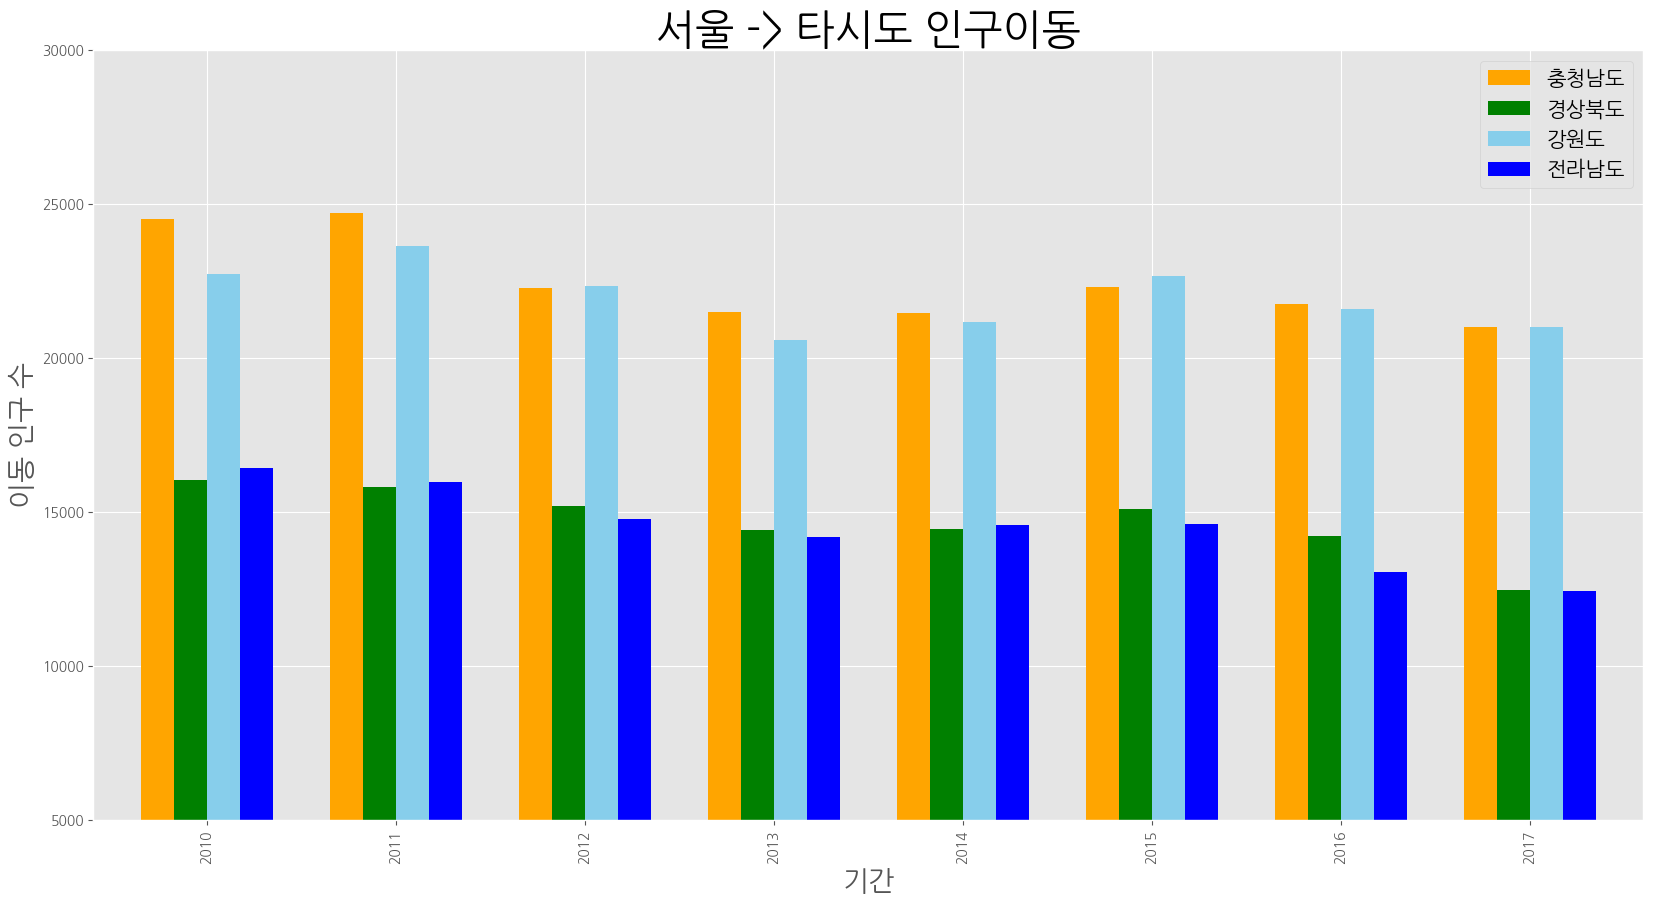

In [17]:
# 예제 4-16: 세로형 막대 그래프

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]
df_4 = df_4.T

# 스타일 서식 지정
plt.style.use('ggplot')

# 데이터프레임의 인덱스를 정수형으로 변경(x축 눈금 라벨 표시)
df_4.index = df_4.index.map(int)

# 막대 그래프 그리기
df_4.plot(kind = 'bar', figsize=(20, 10), width = 0.7,
          color = ['orange','green','skyblue', 'blue'])

plt.title('서울 -> 타시도 인구이동', size = 30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size = 20)
plt.ylim(5000, 30000)
plt.legend(loc = 'best', fontsize = 15)

plt.show()

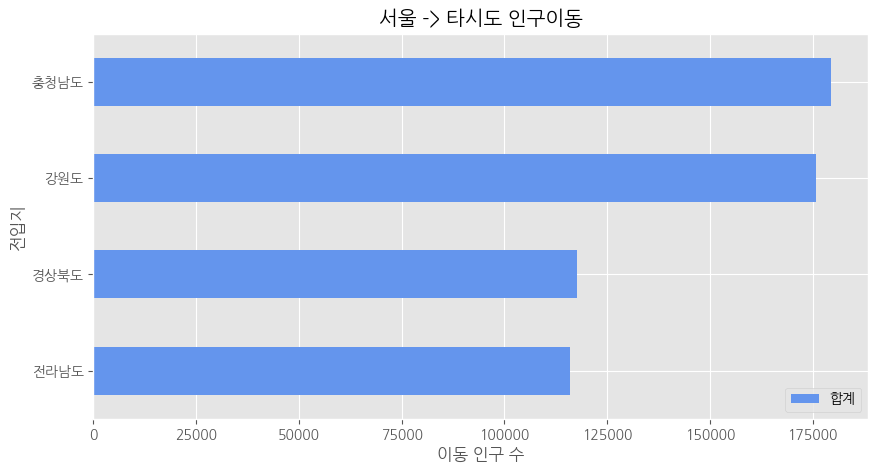

In [18]:
# 예제 4-17: 가로형 막대 그래프

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/시도별_전출입_인구수.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, header=0)

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df = df.ffill()

# 스타일 서식 지정
plt.style.use('ggplot')

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 서울에서 '충청남도', '경상북도', '강원도', '전라남도'로 이동한 인구 데이터 값만 선택
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[['충청남도', '경상북도', '강원도', '전라남도'], col_years]

# 2010-2017년 인구 수를 합계하여 새로운 열로 추가
df_4['합계'] = df_4.sum(axis = 1)

# 가장 큰 값부터 정렬
df_total = df_4[['합계']].sort_values(by = '합계', ascending = True)

# 스타일 서식 지정
plt.style.use('ggplot')

# 수평 막대 그래프 그리기
df_total.plot(kind='barh', color='cornflowerblue', width = 0.5, figsize=(10,5))

plt.title('서울 -> 타시도 인구이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구 수')

plt.show()

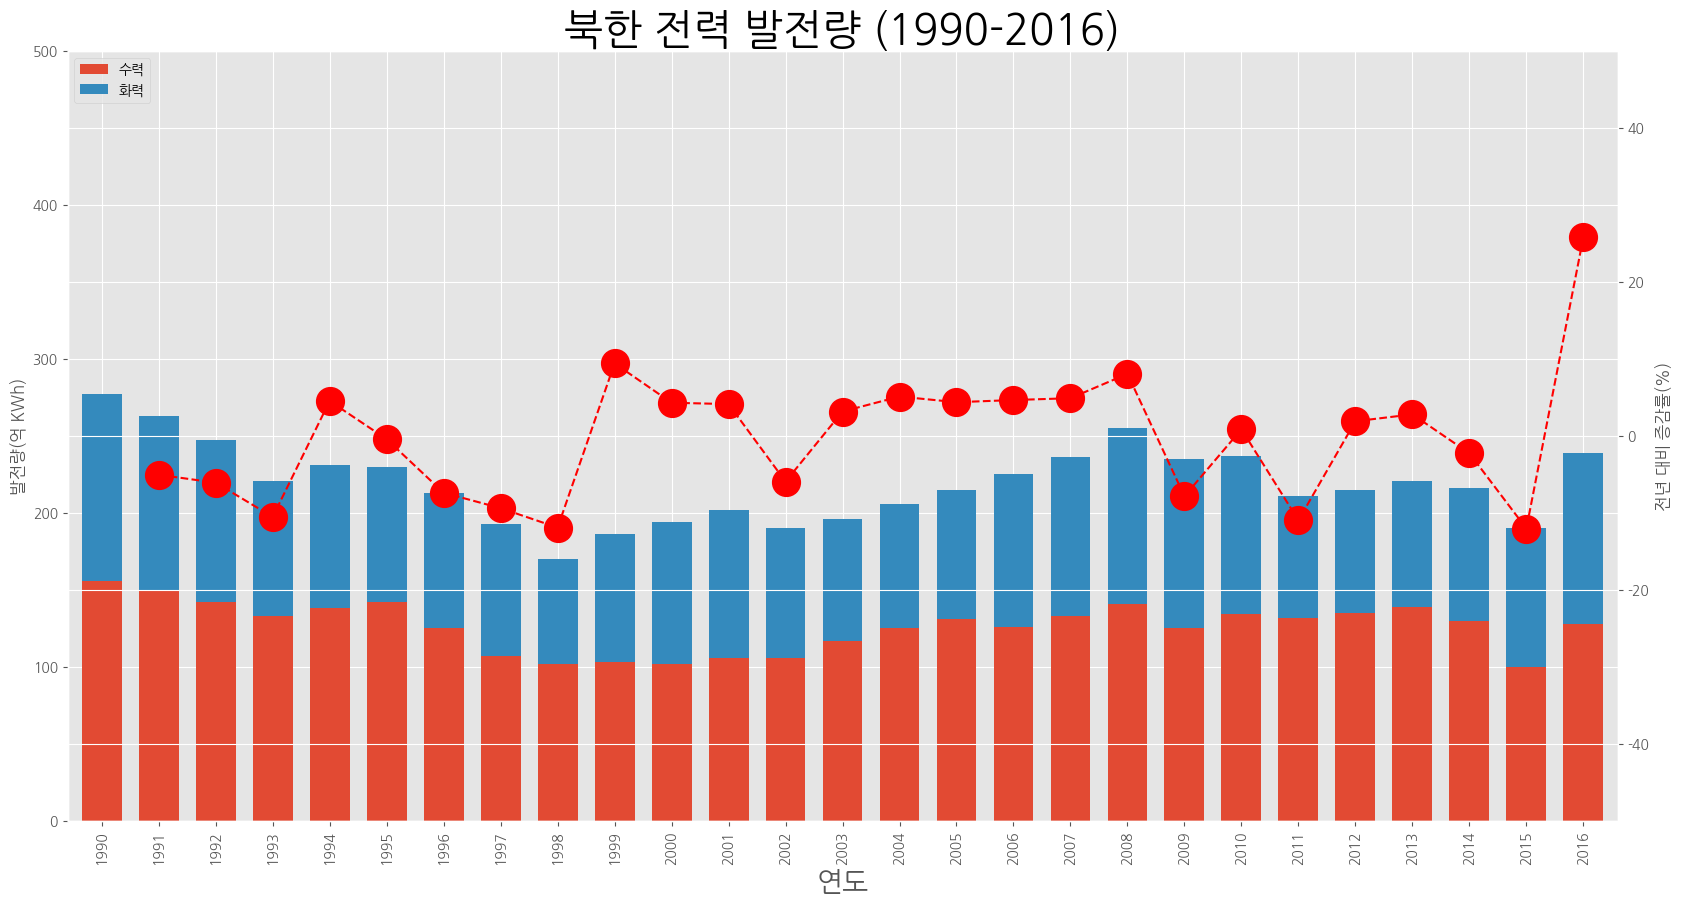

In [19]:
# 예제 4-18: 2축 그래프 그리기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('ggplot')
plt.rcParams['axes.unicode_minus'] = False

# Excel 데이터를 데이터프레임으로 변환

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/남북한발전전력량.xlsx"
df = pd.read_excel(file_path)
df = df.loc[5:9]
df.drop('전력량 (억㎾h)', axis = 'columns', inplace = True)
df.set_index('발전 전력별', inplace = True)
df = df.T

# 증감률(변동률) 계산

df = df.rename(columns = {'합계':'총발전량'})
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df['증감률'] = ((df['총발전량']/df['총발전량 - 1년']) - 1) * 100

# 2축 그래프 그리기
ax1 = df[['수력', '화력']].plot(kind = 'bar', figsize = (20, 10), width=0.7, stacked = True)
ax2 = ax1.twinx()
ax2.plot(df.index, df.증감률, ls='--', marker = 'o', color = 'red', markersize =20,
         label = '전년대비 증감률(%)')
ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

ax1.set_xlabel('연도', size = 20)
ax1.set_ylabel('발전량(억 KWh)')
ax2.set_ylabel('전년 대비 증감률(%)')

plt.title('북한 전력 발전량 (1990-2016)', size = 30)
ax1.legend(loc = 'upper left')

plt.show()

**1-4 히스토그램**

- 변수가 하나인 단변수 데이터의 빈도수를 그래프로 표현
- x축을 같은 크기의 여러 구간으로 나누고 각 구간에 속하는 데이터 값의 개수(빈도)를 y축에 표시
- 구간을 나누는 간격의 크기에 따라 빈도가 달라지고 히스토그램의 모양이 변함


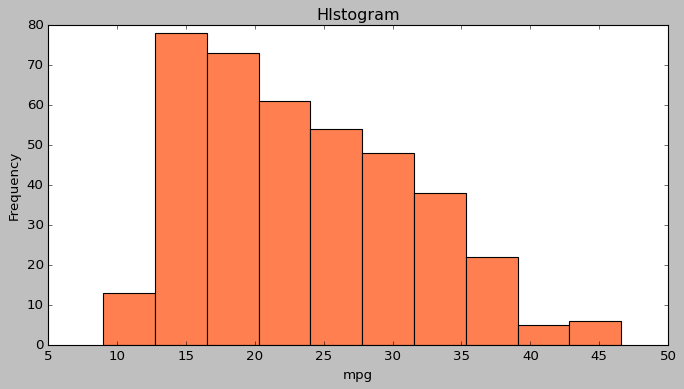

In [20]:
# 예제 4-19: 히스토그램

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('classic')     # 스타일 서식 지정

# read_csv() 함수로 df 생성

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 연비(mpg) 열에 대한 히스토그램 그리기
df['mpg'].plot(kind='hist', bins = 10, color='coral', figsize = (10,5))

# 그래프 꾸미기
plt.title('HIstogram')
plt.xlabel('mpg')
plt.show()

**1-5 산점도**

- 서로 다른 두 변수 사이의 관계를 나타냄, 변수는 연속되는 값을 가짐
- 두 연속 변수의 관계를 보여준다는 점에서 선그래프와 비슷
- 버블차트: 점의 크기에 변화를 주면 모양이 비눗방울 같음, cylinders_size는 0~1 범위의 실수 값의 배열

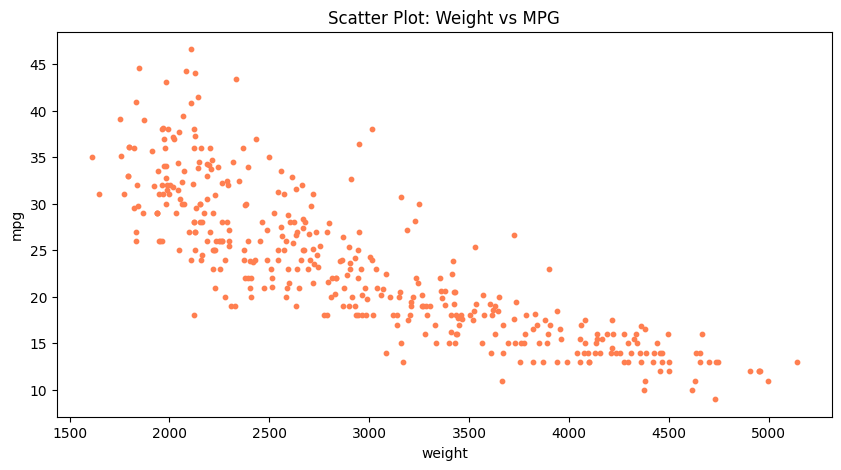

In [21]:
# 예제 4-20: 산점도

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')     # 스타일 서식 지정

# read_csv() 함수로 df 생성

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 연비(mpg)와 치중(weight) 열에 대한 산점도 그리기
df.plot(kind = 'scatter', x='weight', y='mpg', c='coral', s=10, figsize= (10,5))
plt.title('Scatter Plot: Weight vs MPG')
plt.show()

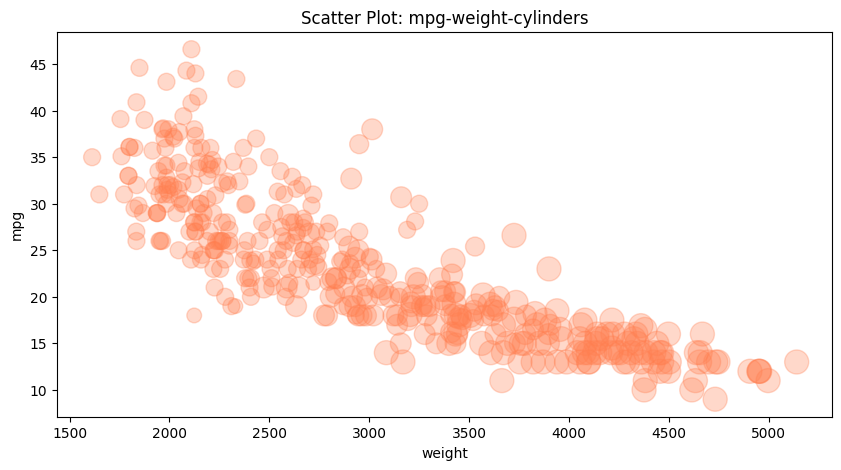

In [22]:
# 예제 4-21: 버블 차트

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')     # 스타일 서식 지정

# read_csv() 함수로 df 생성

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = df.cylinders / df.cylinders.max() * 300

# 연비(mpg)와 치중(weight) 열에 대한 산점도 그리기
df.plot(kind = 'scatter', x='weight', y='mpg', c = 'coral', figsize= (10 ,5),
        s=cylinders_size, alpha = 0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')

plt.show()

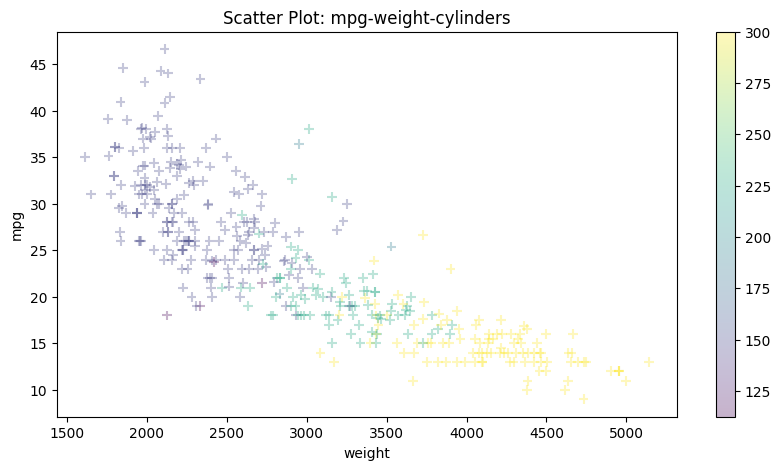

In [23]:
# 예제 4-22: 그림 파일로 저장

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')     # 스타일 서식 지정

# read_csv() 함수로 df 생성

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# cylinders 개수의 상대적 비율을 계산하여 시리즈 생성
cylinders_size = df.cylinders / df.cylinders.max() * 300

# 3개의 변수로 산점도 그리기
df.plot(kind = 'scatter', x='weight', y='mpg', marker = '+', figsize= (10 ,5),
        cmap = 'viridis', c=cylinders_size, s= 50, alpha = 0.3)
plt.title('Scatter Plot: mpg-weight-cylinders')

plt.savefig('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/scatter.png')
plt.savefig('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/scatter_transparent.png', transparent = True)

plt.show()

**1-6 파이 차트**

- 원을 파이 조각처럼 나누어서 표현, 크기는 데이터값의 크기에 비례



           mpg  cylinders  displacement  \
origin                                    
1       5000.8       1556       61229.5   
2       1952.4        291        7640.0   
3       2405.6        324        8114.0   

                                               horsepower    weight  \
origin                                                                
1       130.0165.0150.0150.0140.0198.0220.0215.0225.01...  837121.0   
2       46.0087.0090.0095.00113.090.0070.0076.0060.005...  169631.0   
3       95.0088.0088.0095.0065.0069.0095.0097.0092.009...  175477.0   

        acceleration  model year  \
origin                             
1             3743.4       18827   
2             1175.1        5307   
3             1277.6        6118   

                                                     name  count  
origin                                                            
1       chevrolet chevelle malibubuick skylark 320plym...    249  
2       volkswagen 1131 deluxe sedanpeugeot 50

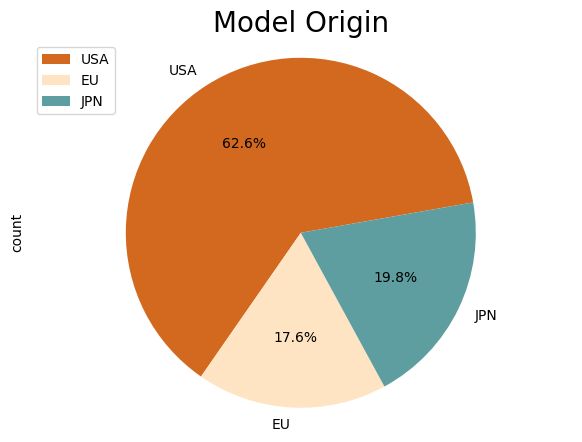

In [24]:
# 예제 4-23: 파이차트

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')     # 스타일 서식 지정

# read_csv() 함수로 df 생성

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 데이터 개수 카운트를 위해 값 1을 가진 열 추가
df['count'] = 1
df_origin = df.groupby('origin').sum()
print(df_origin.head())

# 제조국가(origin) 값을 실제 지역명으로 변경
df_origin.index = ['USA', 'EU', 'JPN']

# 제조국가(origin) 열에 대한 파이차트 그리기 - count 열 데이터 사용
df_origin['count'].plot(kind = 'pie',
                        figsize = (7,5),
                        autopct='%1.1f%%',
                        startangle=10,    # 파이 조각을 나누는 시작점(각도표시)
                        colors =['chocolate','bisque', 'cadetblue']
                        )

plt.title('Model Origin', size = 20)
plt.axis('equal')    # 파이 차트의 비율을 같게(원에 가깝게) 조정
plt.legend(labels = df_origin.index, loc = 'upper left')

plt.show()

**1-7 박스플롯**

- 범주형  데이터의 분포를 파악하는데 적합
- 5개의 통계지표(최소값, 1분위값, 중간값, 3분위값, 최대값) 제공

/tmp/ipykernel_667/3288021371.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(x=[df[df['origin']==1]['mpg'],
/tmp/ipykernel_667/3288021371.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(x=[df[df['origin']==1]['mpg'],


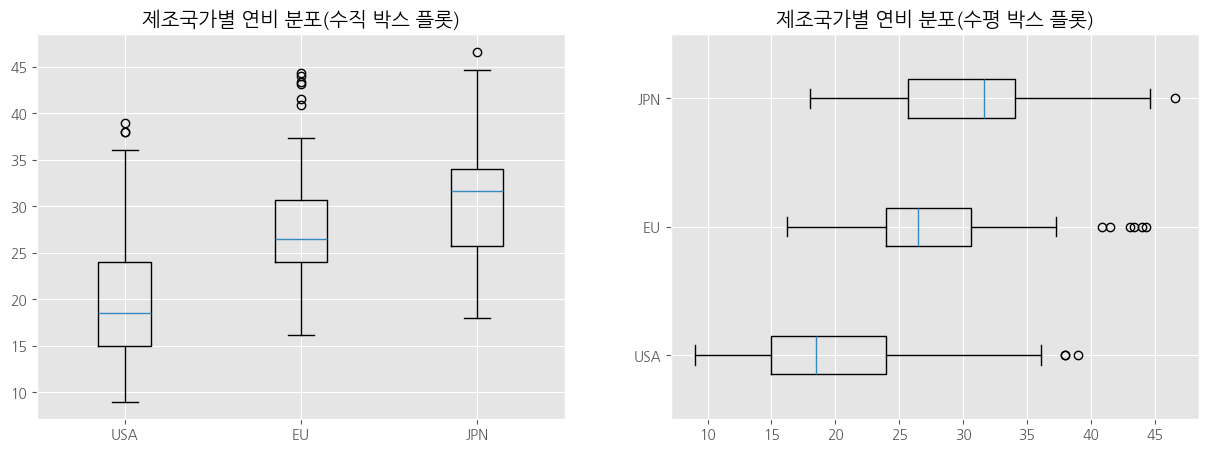

In [25]:
# 예제 4-24: 박스 플롯

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# matplotlib 한글 폰트 오류 문제 해결

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('ggplot')
plt.rcParams['axes.unicode_minus'] = False

file_path = "/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/auto-mpg.csv"
df = pd.read_csv(file_path, header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 그래프 객체 생성(figure에 2개의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# axe 객체에 boxplot 메소드로 그래프 출력

ax1.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']],
            labels=['USA', 'EU', 'JPN'])
ax2.boxplot(x=[df[df['origin']==1]['mpg'],
               df[df['origin']==2]['mpg'],
               df[df['origin']==3]['mpg']],
            labels=['USA', 'EU', 'JPN'],
            vert=False)
ax1.set_title('제조국가별 연비 분포(수직 박스 플롯)')
ax2.set_title('제조국가별 연비 분포(수평 박스 플롯)')
plt.show()


**2 Seaborn 라이브러리 - 고급 그래프 도구**

- Matplotlib의 기능과 스타일을 확장한 파이썬 시각화 도구 버전

In [26]:
# 예제 4-25: titanic 데이터셋

# 라이브러리 불러오기
import seaborn as sns

# titanic 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 데이터 살펴보기
print(titanic.head())
print('\n')
print(titanic.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-

**회귀선이 있는 산점도**

- regplot() 함수: 서로 다른 2개의 연속 변수 사이의 산점도를 그리고 선형회귀분석에 의한 회귀선을 함께 나타냄

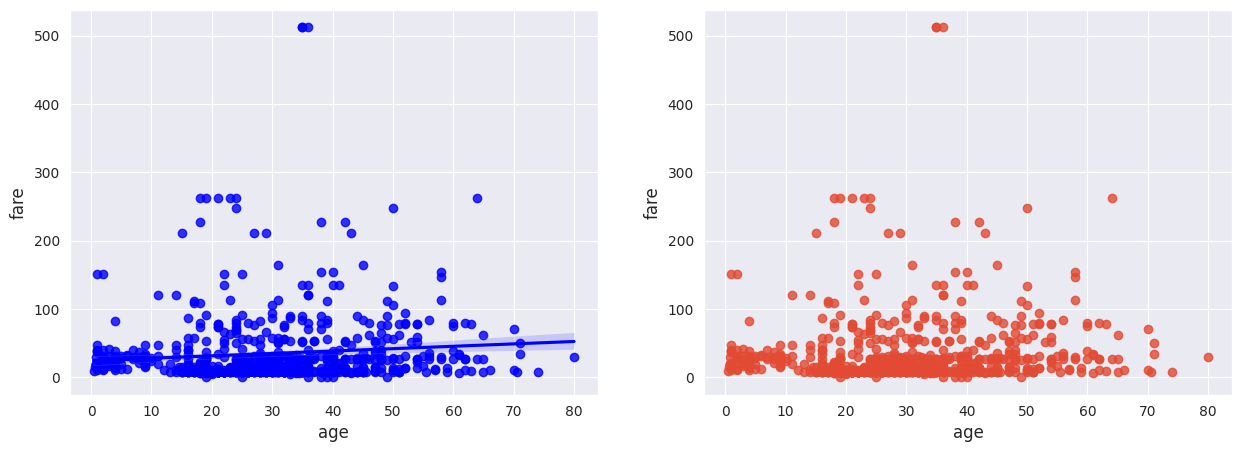

In [27]:
# 예제 4-26: 회귀선이 있는 산점도

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성(figure에 2의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# 그래프 그리기 - 선형회귀선 표시(flt_reg=True)
sns.regplot(x='age', y='fare', data=titanic, ax=ax1, color = 'blue')
# 그래프 그리기 - 선형회귀선 미표시(flt_reg=False)
sns.regplot(x='age', y='fare', data=titanic, ax=ax2,  fit_reg=False)

plt.show()

**히스토그램/커널 밀도 그래프**

- 단변수 데이터의 분포를 확인할 때 distplot() 함수를 이용
- 커닐밀도함수: 그래프와 x축 사이의 면적이 1이 되도록 그리는 밀도 분포 함수

/tmp/ipykernel_667/1544698677.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['fare'], ax=ax1)
/tmp/ipykernel_667/1544698677.py:23: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['fare'], hist=False, ax=ax2)
/tmp/ipykernel_667/1544698677.py:26: UserWarning: 

`distpl

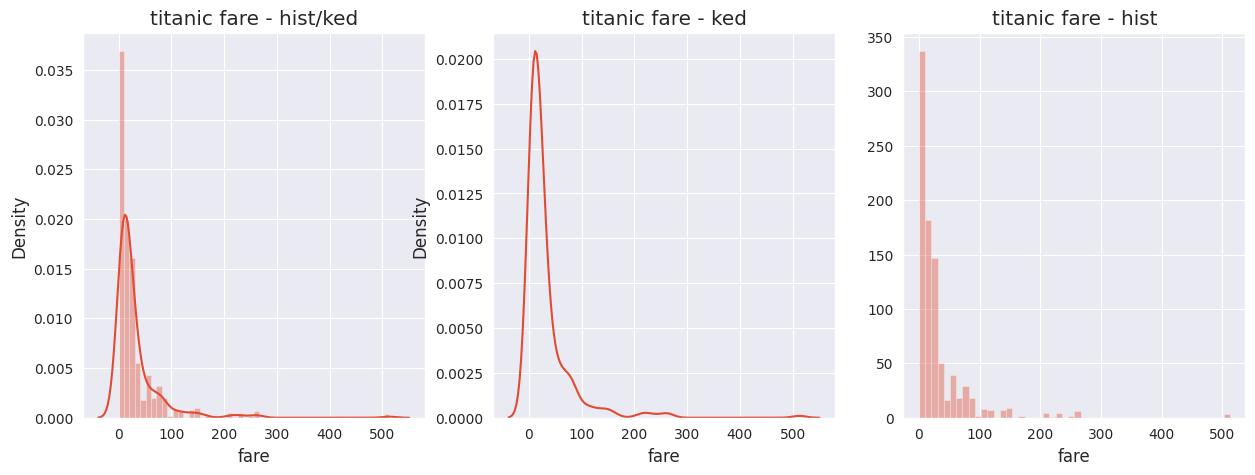

In [28]:
# 예제 4-27: 히스토그램/커닐밀도함수

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성(figure에 3의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

# 기본값
sns.distplot(titanic['fare'], ax=ax1)

# hist=False
sns.distplot(titanic['fare'], hist=False, ax=ax2)

# kde=False
sns.distplot(titanic['fare'], kde=False, ax=ax3)

# 차트제목표시
ax1.set_title('titanic fare - hist/ked')
ax2.set_title('titanic fare - ked')
ax3.set_title('titanic fare - hist')

plt.show()

**히트맵**

- 2개의 범주형 변수를 각각 x,y축에 놓고 데이터를 매트릭스 형태로 분류
- 데이터프레임을 피벗테이블로 정리할 때 한 변수를 행인덱스로, 나머지 변수를 열 이름으로 설정
- 'aggfunc = 'size'' 옵션은 데이터 값의 크기를 기준으로 집계함

/tmp/ipykernel_667/1444069832.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = titanic.pivot_table(index =['sex'], columns =['class'], aggfunc='size')


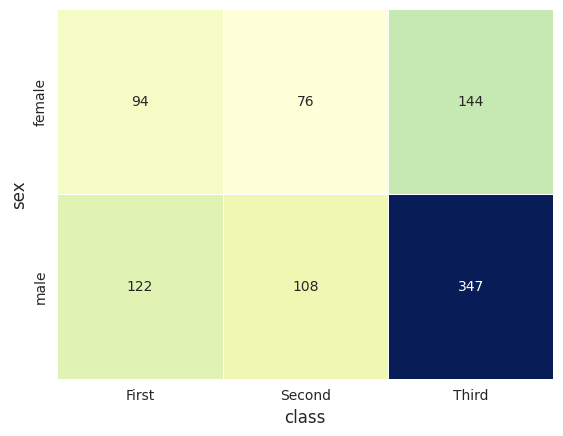

In [29]:
# 예제 4-28: 히트맵

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 피벗테이블로 범주형 변수를 각각 행, 열로 재구분하여 정리
table = titanic.pivot_table(index =['sex'], columns =['class'], aggfunc='size')

# 히트맵 그리기
sns.heatmap(table,
            annot=True, fmt='d',    # 데이터값 표시 여부, 정수형 포맷
            cmap='YlGnBu',
            linewidths=.5,
            cbar = False)

plt.show()

**범주형 데이터의 산점도**

- 범주형 변수에 들어있는 각 범주별 데이터의 분포를 확인하는 방법
- stripplot() or swarmplot()
- swarmplot(): 데이터의 분산까지 고려, 데이터 포인트가 서로 중복되지 않도록 그림-> 데이터가 퍼져있는 정도를 입체적으로 볼 수 있음


/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 53.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 29.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 61.4% of the points cannot be plac

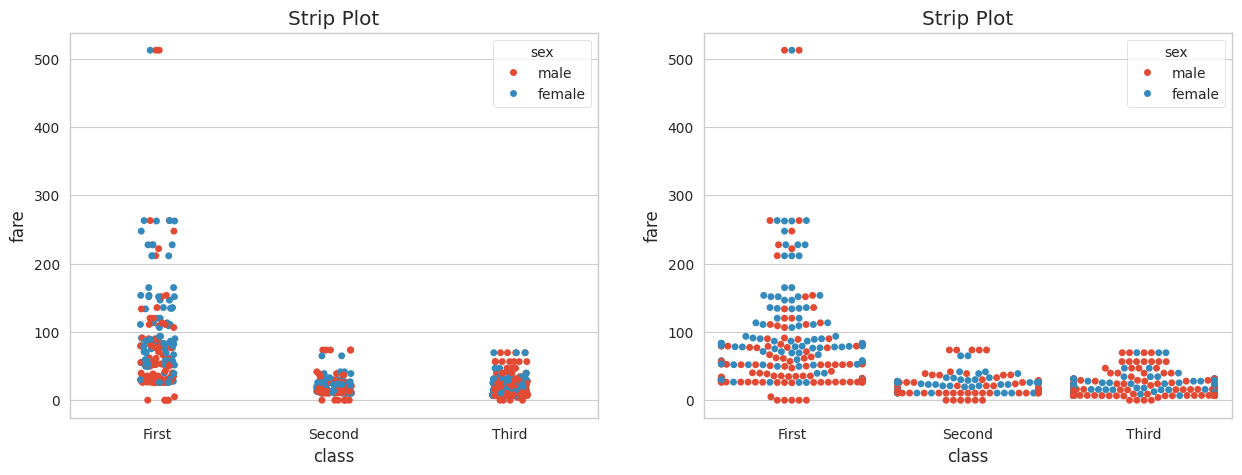

In [30]:
# 예제 4-29: 범주형 데이터의 산점도

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성(figure에 2의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# 이산형 변수의 분포 - 데이터 분산 미고려
sns.stripplot(x='class', y='fare', data=titanic, ax=ax1, hue='sex')

# 이산형 변수의 분포 - 데이터 분산 고려
sns.swarmplot(x='class', y='fare', data=titanic, ax=ax2, hue='sex')

# 차트 제목 표시
ax1.set_title('Strip Plot')
ax2.set_title('Strip Plot')

plt.show()

**막대 그래프**



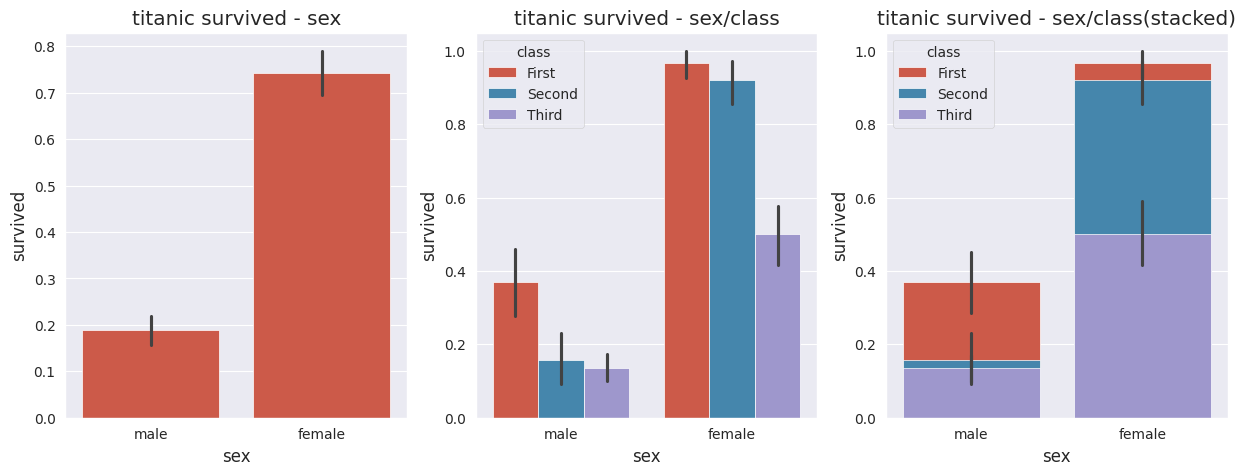

In [31]:
# 예제 4-30: 막대 그래프

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성(figure에 3의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

# x축, y축에 변수 할당하고 hue 옵션을 추가하여 누적출력
sns.barplot(x='sex', y='survived', data=titanic, ax=ax1)
sns.barplot(x='sex', y='survived', hue='class', data=titanic, ax=ax2)

# x축, y축에 변수 할당하고 hue 옵션을 추가하여 누적 출력
sns.barplot(x='sex', y='survived', hue='class', dodge=False, data=titanic, ax=ax3)

# 차트 제목 표시
ax1.set_title('titanic survived - sex')
ax2.set_title('titanic survived - sex/class')
ax3.set_title('titanic survived - sex/class(stacked)')

plt.show()


**빈도 그래프**

- countplot(): 범주에 속하는 데이터의 개수를 막대그래프로 나타냄

/tmp/ipykernel_667/4061838421.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class',palette='Set1', data=titanic, ax=ax1)


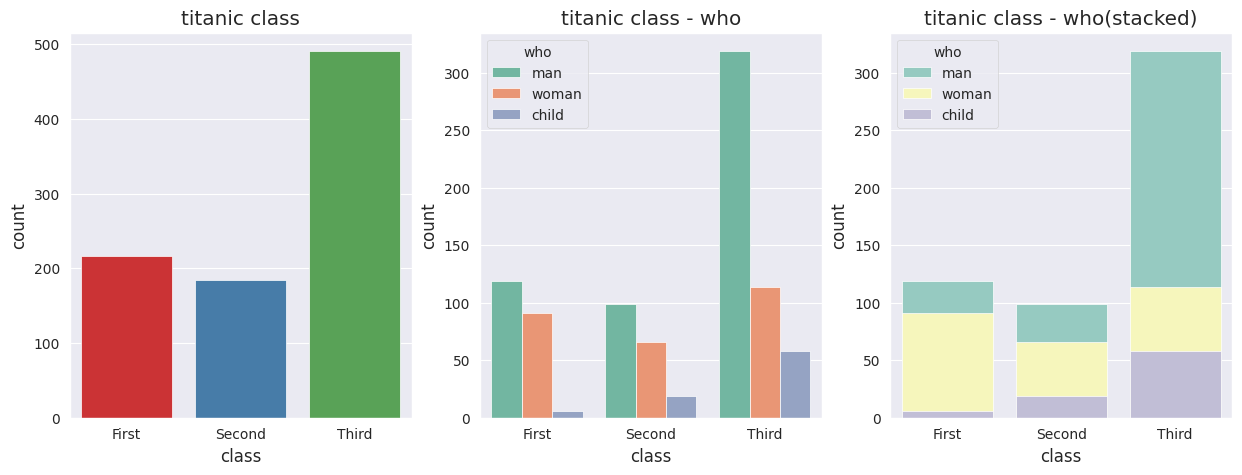

In [32]:
# 예제 4-31: 빈도 그래프

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('darkgrid')

# 그래프 객체 생성(figure에 3의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

# 기본값
sns.countplot(x='class',palette='Set1', data=titanic, ax=ax1)

# hue 옵션에 who 추가
sns.countplot(x='class', hue='who', palette='Set2', data=titanic, ax=ax2)

# dodge = False 옵션 추가(축 방향으로 분리하지 않고 누적 그래프 출력)
sns.countplot(x='class', hue='who', palette='Set3', dodge=False, data=titanic, ax=ax3)

# 차트 제목 표시
ax1.set_title('titanic class')
ax2.set_title('titanic class - who')
ax3.set_title('titanic class - who(stacked)')

plt.show()

**박스플롯/바이올린 그래프**

- 박스플롯: 범주형 데이터 분포와 주요 통계지표 제공
- 박스플롯만으로는 데이터가 퍼져있는 분산의 정도를 정확히 알기어려워 커널밀도함수 그래프를 y축 방향에 추가하여 바이올림 그래프를 그리는 경우도 있음

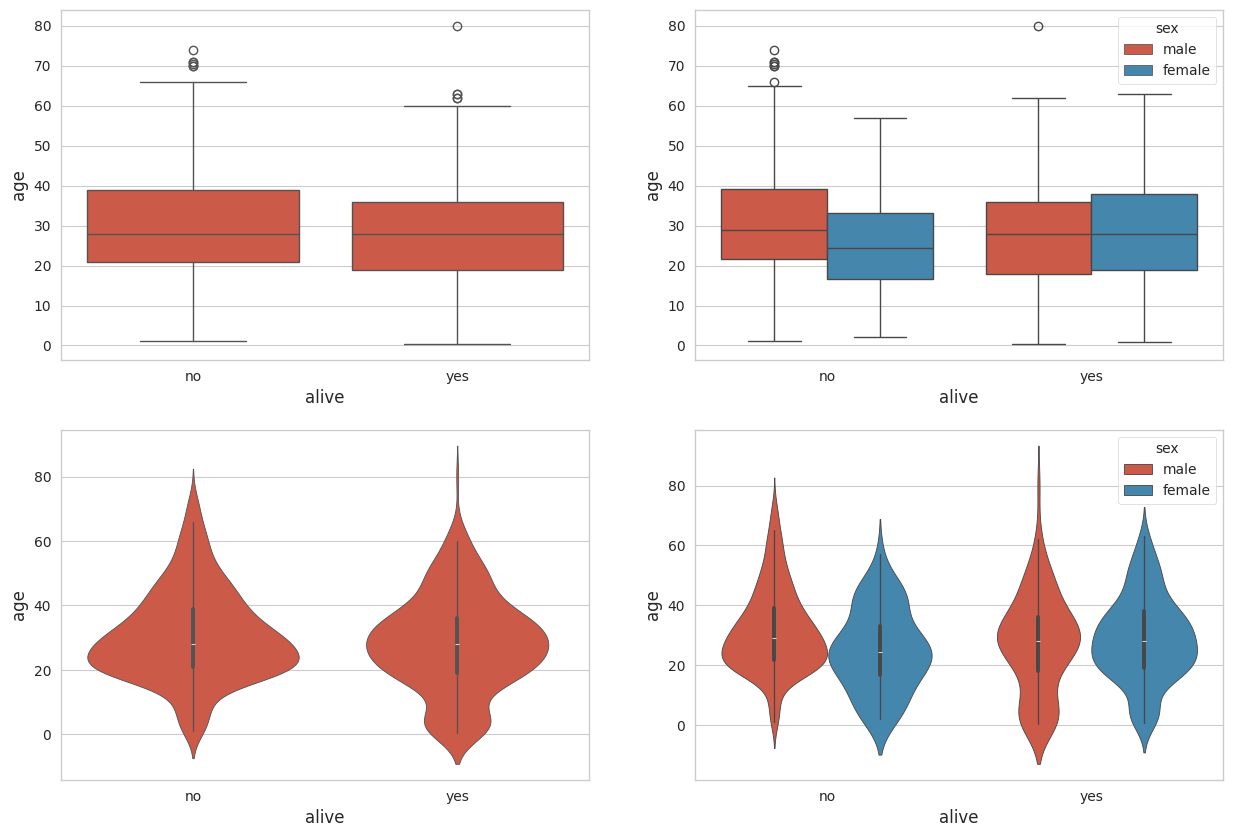

In [33]:
# 예제 4-32: 박스플롯/바이올린 그래프

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 그래프 객체 생성(figure에 4의 서브 플롯 생성)
fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

# 박스플롯 - 기본값
sns.boxplot(x='alive', y='age', data=titanic, ax=ax1)

# 바이올린 그래프 - hue 옵션 추가
sns.boxplot(x='alive', y='age', hue='sex', data=titanic, ax=ax2)

# 박스플롯 - 기본값
sns.violinplot(x='alive', y='age', data=titanic, ax=ax3)

# 바이올린 그래프 - hue 변수 추가
sns.violinplot(x='alive', y='age', hue='sex', data=titanic, ax=ax4)

plt.show()

**조인트 그래프**

- 산점도를 기본으로 표시
- x-y축에 각 변수에 대한 히스토그램을 동시에 보여줌
- 두 변수 관계와 데이터가 분산되어있는 정도를 한눈에 파악하기 좋음
- 예제에서 산점도, 회귀선 추가, 육각 산점도, 커널 밀집 그래프 순으로 조인트 그래프를 그리고 차이를 비교함

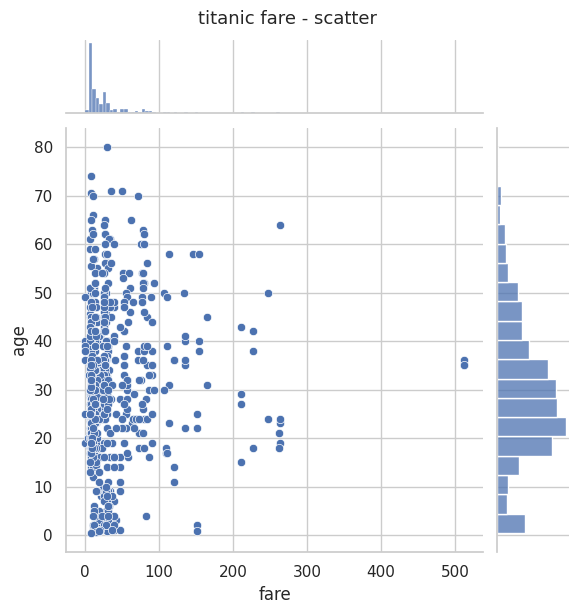

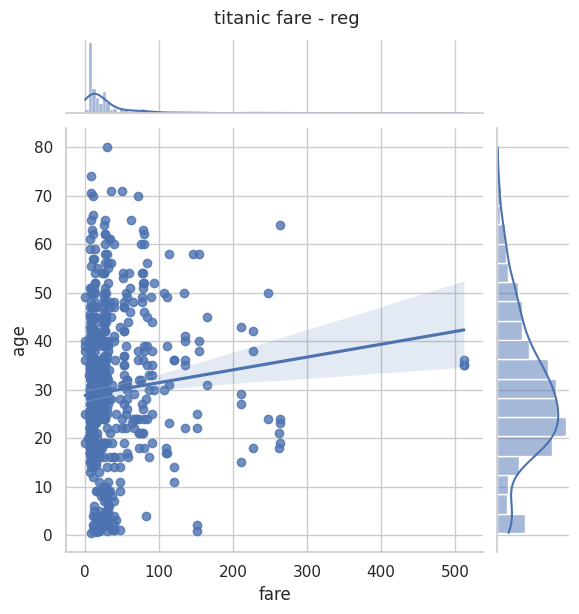

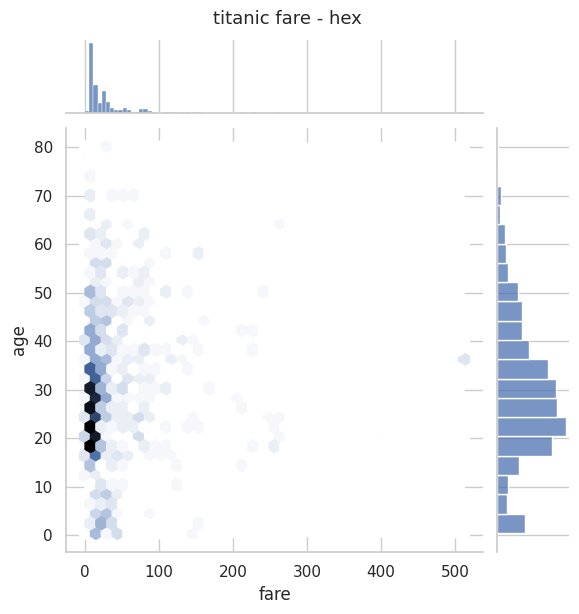

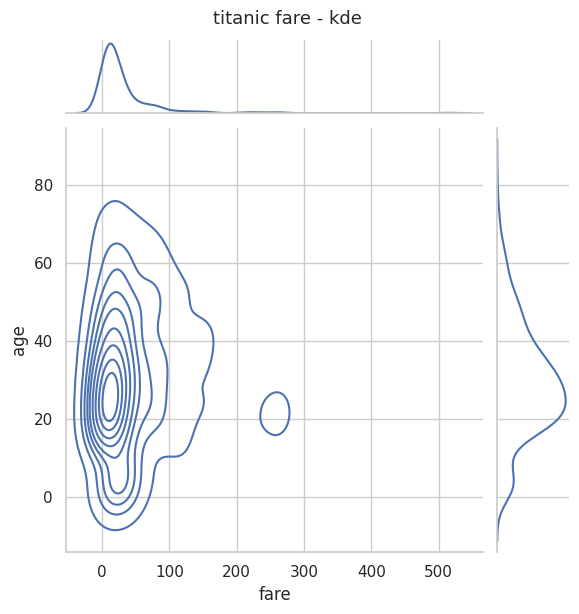

In [42]:
# 예제 4-33: 조인트 그래프

import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_theme(style='whitegrid')

# j1 - 산점도
j1 = sns.jointplot(x='fare', y='age', data=titanic)
j1.fig.suptitle('titanic fare - scatter', size=13, y=1.02)
plt.show()

# j2 - 회귀선
j2 = sns.jointplot(x='fare', y='age', kind='reg', data=titanic)
j2.fig.suptitle('titanic fare - reg', size=13, y=1.02)
plt.show()

# j3 - 육각
j3 = sns.jointplot(x='fare', y='age', kind='hex', data=titanic)
j3.fig.suptitle('titanic fare - hex', size=13, y=1.02)
plt.show()

# j4 - 커널 밀도
j4 = sns.jointplot(x='fare', y='age', kind='kde', data=titanic)
j4.fig.suptitle('titanic fare - kde', size=13, y=1.02)
plt.show()

**조건을 적용하여 화면을 그리드로 분할하기**

- FacetGrid(): 행, 열 방향으로 서로 다른 조건을 적용해 여러개의 서브 플롯을 생성
- 각 서브 플롯에 적용할 그래프 종류를 map() 메소드를 이용해 그리드 객체에 전달

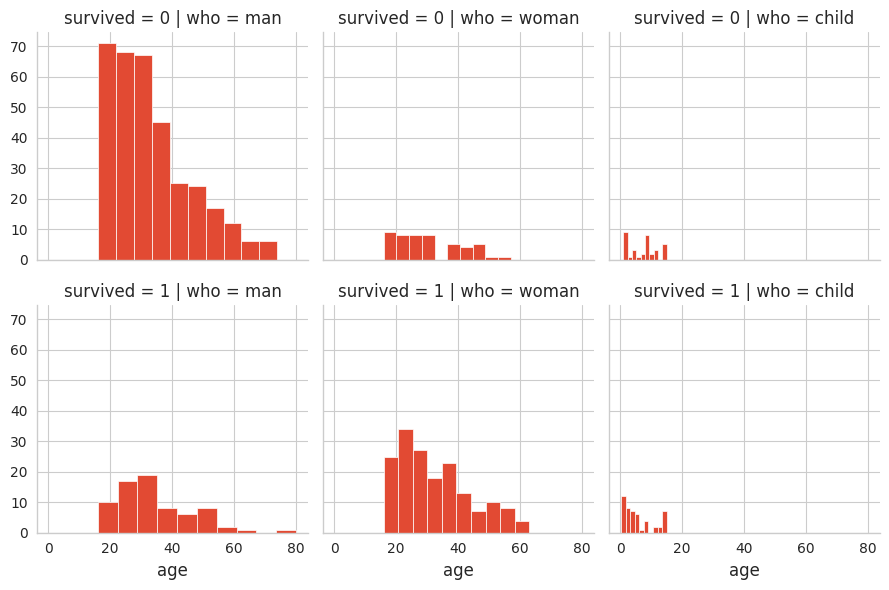

In [35]:
# 예제 4-34: 조건에 맞게 화면 분할

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# 조건에 따라 그리드 나누기
g = sns.FacetGrid(data = titanic, col='who', row ='survived')

# 그래프 적용하기
g = g.map(plt.hist, 'age')   # 나이 기준으로 히스토그램



**이변수 데이터의 분포**

- pairplot(): 인자로 전달되는 데이터프레임의 열(변수)를 두 개씩 짝을 지을 수 있는 모든 조합에 대해 표현
- 그래프를 그리기 위해 만들어진 짝의 개수만큼 화면을 그리드로 나눔
- 같은 변수끼리 짝을 이루는 대각선 방향으로는 히스토그램을 그리고 서로 다른 변수 간에는 산점도를 그림

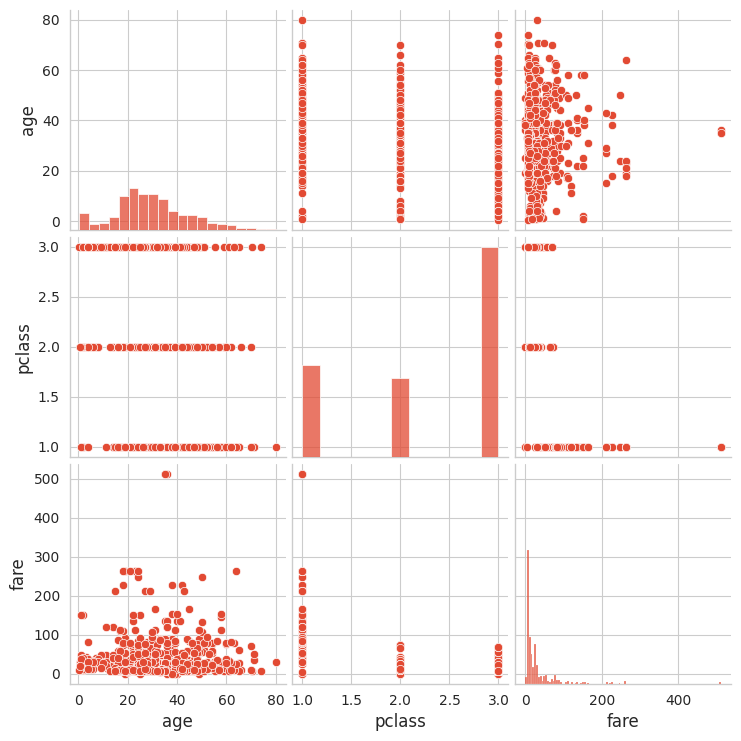

In [36]:
# 예제 4-35: 이변수 데이터 분포

# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 제공 데이터셋 가져오기
titanic = sns.load_dataset('titanic')

# 스타일 테마 설정(5가지: darkgrid, whitegrid, dark, white, ticks)
sns.set_style('whitegrid')

# titanic 데이터셋 중에서 분석 데이터 선택하기
titanic_pair = titanic[['age', 'pclass','fare']]

# 조건에 따라 그리드 나누기
g = sns.pairplot(titanic_pair)

# 3 Folium 라이브러리 - 지도 활용

**지도 만들기**

- Folium은 웹기반 지도를 만들기 때문에 IDE에서 실행해도 지도가 표시되지 않음->오직 웹환경에서만 지도를 확인할 수 있음
- 지도를 보려면 지도 객체에 save() 메소드를 적용하여 HTML 파일로 저장하고, 웹브라우저에서 파일을 열어서 확인해야함
- jupyter Notebook등 웹 기반 IDE에서는 지도 객체를 바로 확인 가능

In [37]:
# 예제 4-36: 지도 만들기

# 라이브러리 불러오기
import folium

# 서울 지도 만들기
seoul_map = folium.Map(location=[37.55,126.98],
                       tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
                       attr='Tiles &copy; Esri', zoom_start=12)

# 지도를 HTML 파일로 저장하기
# seoul_map.save('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/seoul.html')

seoul_map

**지도 스타일 적용하기**

- Map() 함수에 titles 옵션을 적용하면 지도에 적용하는 스타일을 변경하여 지정 가능
- Stamen Terrain vs Stamen Toner
- Stamen Terrain 맵에서 산악 지형 등의 지형이 선명하게 드러남

In [38]:
# 예제 4-37: 지도 스타일 적용

# 라이브러리 불러오기
import folium

# 서울 지도 만들기
# 지형/일반 지도
seoul_map2 = folium.Map(
    location=[37.55, 126.98],
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri',
    zoom_start=12
)

# 위성 지도
seoul_map3 = folium.Map(
    location=[37.55, 126.98],
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri',
    zoom_start=15
)

seoul_map2
seoul_map3

# 지도를 HTML 파일로 저장하기
# seoul_map2.save('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/seoul2.html')
# seoul_map3.save('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/seoul3.html')

**지도에 마커 표시하기**

- Marker() 함수에 위도, 경도 정보 전달
- popup 옵션 추가하면 마커 클릭했을 때 팝업창에 표시해주는 텍스트 넣을 수 있음

In [39]:
# 예제 4-38: 지도에 마커 표시하기

# 라이브러리 불러오기
import pandas as pd
import folium

# 대학교 리스트를 데이터프레임으로 변환
df = pd.read_excel('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/서울지역_대학교_위치.xlsx')

# 서울 지도 만들기
seoul_map = folium.Map(location=[37.55, 126.98],
                       tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
                       attr='Tiles &copy; Esri',
                       zoom_start=12)

# 대학교 위치 정보를 Marker로 표시
for name, lat, lng in zip(df.index, df.위도, df.경도):
  folium.Marker([lat, lng], popup=name).add_to(seoul_map)

seoul_map

**지도에 원형 마커 표시**

- CIrcleMarker() 사용
- 원형 마커의 크기, 색상, 투명도 등을 설정 가능

In [40]:
# 예제 4-39: 지도에 원형 마커 표시하기

# 라이브러리 불러오기
import pandas as pd
import folium

# 대학교 리스트를 데이터프레임으로 변환
df = pd.read_excel('/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/서울지역_대학교_위치.xlsx')

# 서울 지도 만들기
seoul_map = folium.Map(location=[37.55, 126.98],
                       tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
                       attr='Tiles &copy; Esri',
                       zoom_start=12)

# 대학교 위치 정보를 Marker로 표시
for name, lat, lng in zip(df.index, df.위도, df.경도):
  folium.CircleMarker([lat, lng], radius=10,
                fill=True,
                fill_color = 'coral',
                fill_opacity = 0.7,
                popup=name).add_to(seoul_map)

seoul_map

**지도 영역에 단계구분도 표시하기**

- 행정구역과 같이 지도 상의 어떤 경계에 둘러싸인 영역에 색을 칠하거나 음영 등으로 정보를 나타내는 시각화 방법
- 전달하려는 정보의 값이 커지면 영역에 칠해진 색이나 음영이 진해짐

In [41]:
# 예제 4-40: 지도 영역에 단계구분도 표시하기

# 라이브러리 불러오기
import pandas as pd
import folium
import json

# 경기도 인구변화 데이터를 불러와서 데이터프레임으로 변환
file_path = '/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/경기도인구데이터.xlsx'
df = pd.read_excel(file_path, index_col='구분')
df.columns = df.columns.map(str)

# 경기도 시군구 경계 정보를 가진 geo-json 파일 불러오기
geo_path = '/content/drive/MyDrive/[980-8]예제파일_파이썬 머신러닝 판다스 데이터 분석(개정판)/pandas-data-analysis-main/part4/data/경기도행정구역경계.json'
try:
  geo_data = json.load(open(geo_path, encoding='utf-8'))
except:
  geo_data = json.load(open(geo_path, encoding='utf-8-sig'))

# 경기도 지도 만들기
g_map = folium.Map(location=[37.5502, 126.982],
                   tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
                       attr='Tiles &copy; Esri',
                       zoom_start=12)

# 출력할 연도 선택(2007-2017년 중에서 선택)
year = '2017'

# Choropleth 클래스로 단계구분도 표시하기
folium.Choropleth(geo_data=geo_data,
                  data = df[year],
                  columns = [df.index, df[year]],
                  fill_color = 'YlOrRd', fill_opacity = 0.7, line_opacity = 0.3,
                  threshold_scale =[10000, 100000, 300000, 500000, 700000],
                  key_on='feature.properties.name',
                  ).add_to(g_map)

g_map